# Random Forest — Filter Feature Selection

**Dataset:** CIC-IDS 2018 (training) | CIC-IDS 2017 (cross-dataset evaluation)

**Feature Selection:** Filter method — Variance Threshold + Correlation Filtering

**Pipeline:** Load CIC-2018 → Label grouping → Clean data → Low-variance removal → Outlier removal (Z-score) → Correlation filtering → Label encoding → Train/test split → Model training → Evaluation → Cross-dataset validation (CIC-2017)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../../../dataset/cic2018_balanced_dataset_standardized.parquet"
raw_data = pd.read_parquet(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


,Protocol,Timestamp,Dst Port,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Packets/s,Bwd Packets/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Header Length.1,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6.0,14/02/2018 08:53:42,60556.0,157.0,2.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,12738.853516,157.0,0.000000e+00,157.0,157.0,157.0,157.00,0.0,157.0,157.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,12738.853516,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000,0.000000,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,255.0,-1.0,0.0,20.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
1,6.0,14/02/2018 10:38:48,80.0,53993792.0,2.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.037041,53993792.0,0.000000e+00,53993792.0,53993792.0,53993792.0,53993792.00,0.0,53993792.0,53993792.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,0.037041,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000,0.000000,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,279.0,-1.0,0.0,20.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
2,6.0,14/02/2018 09:38:17,443.0,61113950.0,16.0,14.0,1578.0,2749.0,538.0,0.0,98.625,178.133987,1116.0,0.0,196.357147,371.917389,70.802162,0.490886,2107377.5,4.100328e+06,10012729.0,19.0,61113950.0,4074263.25,5012311.5,10024262.0,315.0,61102345.0,4700180.5,5125839.0,10024270.0,284.0,0.0,0.0,0.0,0.0,332.0,364.0,0.261806,0.229080,0.0,1116.0,139.580643,280.809509,78853.984375,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,144.233337,98.625,196.357147,332.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,1578.0,14.0,2749.0,8192.0,131.0,11.0,20.0,83368.664062,175935.75,442496.0,11484.0,9992150.0,33221.078125,10012729.0,9924726.0,Benign
3,17.0,14/02/2018 11:19:03,53.0,79651.0,1.0,1.0,35.0,51.0,35.0,35.0,35.000,0.000000,51.0,51.0,51.000000,0.000000,1079.710205,25.109541,79651.0,0.000000e+00,79651.0,79651.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,12.554770,12.554770,35.0,51.0,40.333332,9.237604,85.333336,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,60.500000,35.000,51.000000,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,35.0,1.0,51.0,-1.0,-1.0,0.0,8.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
4,17.0,14/02/2018 09:19:31,53.0,12230.0,1.0,1.0,55.0,83.0,55.0,55.0,55.000,0.000000,83.0,83.0,83.000000,0.000000,11283.728516,163.532303,12230.0,0.000000e+00,12230.0,12230.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,81.766151,81.766151,55.0,83.0,64.333336,16.165808,261.333344,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,96.500000,55.000,83.000000,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,55.0,1.0,83.0,-1.0,-1.0,0.0,8.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263642,6.0,23/02/2018 03:17:24,80.0,46.0,2.0

## 2. Label Distribution

Visualize the raw label distribution in the CIC-IDS 2018 dataset before any grouping.

Label
Benign                      49999
DDOS attack-HOIC            25000
DDoS attacks-LOIC-HTTP      25000
DoS attacks-Hulk            25000
DoS attacks-SlowHTTPTest    25000
DoS attacks-GoldenEye       25000
SSH-Bruteforce              25000
FTP-BruteForce              25000
Infilteration               25000
DoS attacks-Slowloris       10990
DDOS attack-LOIC-UDP         1730
Brute Force -Web              611
Brute Force -XSS              230
SQL Injection                  87
Name: count, dtype: Int64

% distribution:
Label
Benign                      18.96
DDOS attack-HOIC             9.48
DDoS attacks-LOIC-HTTP       9.48
DoS attacks-Hulk             9.48
DoS attacks-SlowHTTPTest     9.48
DoS attacks-GoldenEye        9.48
SSH-Bruteforce               9.48
FTP-BruteForce               9.48
Infilteration                9.48
DoS attacks-Slowloris        4.17
DDOS attack-LOIC-UDP         0.66
Brute Force -Web             0.23
Brute Force -XSS             0.09
SQL Injection              

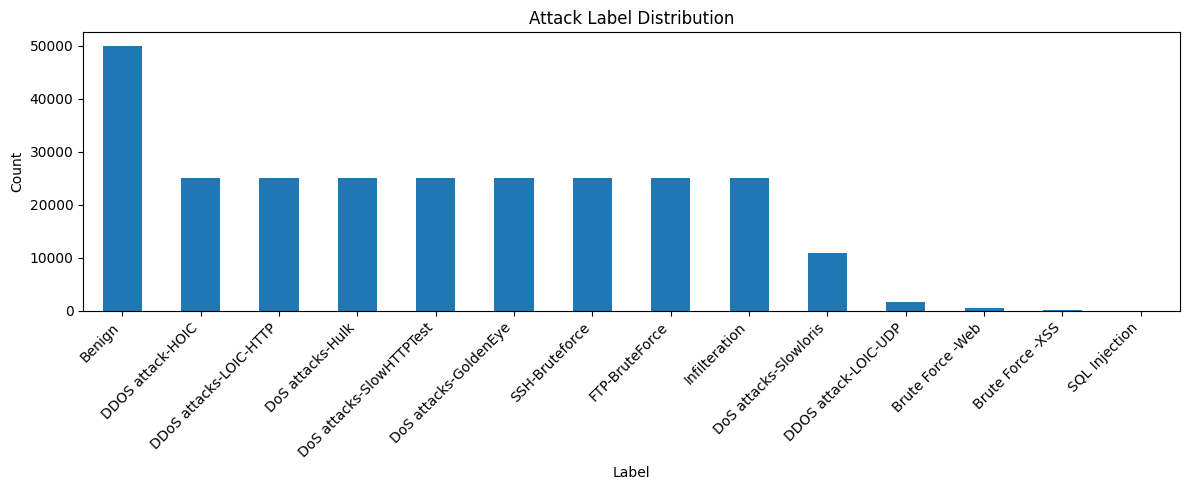

In [2]:
# ── Label distribution ──────────────────────────────────────────────────────
label_counts = df['Label'].value_counts()
print(label_counts)
print(f"\n% distribution:\n{(label_counts / len(df) * 100).round(2)}")

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## 3. Group Attack Labels

Map fine-grained CIC-IDS 2018 attack sub-types into 5 high-level categories: BENIGN, DoS, DDoS, BruteForce, Infiltration. Rows with unmapped labels are discarded.

In [3]:

# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'Benign': 'BENIGN',

    # DoS / DDoS
    'DoS attacks-Hulk': 'DoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-Slowhttptest': 'DoS',
    
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDoS attack-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',

    # Brute Force
    'FTP-BruteForce': 'BruteForce',
    'SSH-Bruteforce': 'BruteForce',
    
    'Brute Force -Web': 'BruteForce',
    'Brute Force -XSS': 'BruteForce',

    'Infilteration': 'Infiltration',  
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  DoS                      60,990  (25.75%)
  BruteForce               50,841  (21.47%)
  DDoS                     50,000  (21.11%)
  BENIGN                   49,999  (21.11%)
  Infiltration             25,000  (10.56%)


## 4. Check Missing and Infinity Values

Identify any NaN or ±inf values in the dataset before cleaning.

In [4]:
# ── Check missing / infinity values ─────────────────────────────────────────
missing = df.isnull().sum()
print("MISSING VALUES\n", missing[missing > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = {col: np.isinf(df[col]).sum()
              for col in numeric_cols if np.isinf(df[col]).sum() > 0}
print("\nINFINITY VALUES")
print(inf_counts if inf_counts else "None")


MISSING VALUES
 Flow Byts/s    386
dtype: int64

INFINITY VALUES
{'Flow Byts/s': np.int64(215), 'Flow Pkts/s': np.int64(601)}


## 5. Handle Infinity and Missing Values

Replace ±inf with NaN, then fill NaN values using the column median to preserve feature distributions without introducing bias.

In [5]:
# ── Handle inf → NaN → fill with median ─────────────────────────────────────
df_processed = df.copy()
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)

numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"NaN remaining : {df_processed.isnull().sum().sum()}")
print(f"Shape         : {df_processed.shape}")


NaN remaining : 0
Shape         : (236830, 81)


/tmp/ipykernel_2364/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_2364/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

## 6. Drop Identifier and Metadata Columns

Remove non-feature columns (Flow ID, IP addresses, timestamps, port numbers) that carry no predictive value and could cause data leakage.

In [6]:
# ── Drop identifier / metadata columns ──────────────────────────────────────
keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop = [c for c in df_processed.columns
                if any(k in c.lower() for k in keywords)]

df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Dropped : {cols_to_drop}")
print(f"Shape   : {df_processed.shape}")


Dropped : ['Timestamp', 'Dst Port']
Shape   : (236830, 79)


## 7. Remove Low-Variance Features

Apply `VarianceThreshold(threshold=0.01)` to drop near-constant features that carry no discriminative information for classification.

In [7]:
# ── Remove low-variance features ─────────────────────────────────────────────
from sklearn.feature_selection import VarianceThreshold

y = df_processed['Label']
X = df_processed.drop('Label', axis=1)

selector = VarianceThreshold(threshold=0.01)
X_hv = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()].tolist()

df_processed = pd.DataFrame(X_hv, columns=selected_features)
df_processed['Label'] = y.values

print(f"Features : {X.shape[1]} → {len(selected_features)} (removed {X.shape[1]-len(selected_features)})")
print(f"Shape    : {df_processed.shape}")


Features : 78 → 67 (removed 11)
Shape    : (236830, 68)


## 8. Outlier Removal (Z-score)

Remove samples whose feature values exceed 3 standard deviations (|Z-score| > 3) to reduce noise and improve model generalization.

In [8]:
# ── Remove outliers via Z-score (threshold = 3) ──────────────────────────────
from scipy import stats

X_temp = df_processed.drop('Label', axis=1)
y_temp = df_processed['Label']

mask = (np.abs(stats.zscore(X_temp)) < 3).all(axis=1)
df_processed = X_temp[mask].copy()
df_processed['Label'] = y_temp[mask]

print(f"Removed  : {(~mask).sum()} outliers ({(~mask).mean()*100:.2f}%)")
print(f"Shape    : {df_processed.shape}")


Removed  : 81953 outliers (34.60%)
Shape    : (154877, 68)


## 9. Drop Highly Correlated Features

Remove one feature from each pair with Pearson correlation > 0.95 to eliminate redundancy and reduce multicollinearity.

In [9]:
# ── Drop highly correlated features (r > 0.95) ───────────────────────────────
X_for_corr = df_processed.drop('Label', axis=1)
upper = X_for_corr.corr().abs().where(
    np.triu(np.ones(X_for_corr.shape[1], dtype=bool), k=1))
to_drop = [c for c in upper.columns if upper[c].max() > 0.95]

df_processed.drop(columns=to_drop, inplace=True)
print(f"Dropped  : {len(to_drop)} correlated features")
print(f"Shape    : {df_processed.shape}")


Dropped  : 32 correlated features
Shape    : (154877, 36)


## 10. Label Encoding

Encode string class labels into integer indices using `LabelEncoder`. Save the fitted encoder to `label_encoder.pkl1` for later use during cross-dataset evaluation.

In [10]:
# ── Label encoding ───────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

with open('label_encoder.pkl1', 'wb') as f:
    pickle.dump(le, f)

for idx, label in enumerate(le.classes_):
    print(f"{idx}: {label}  ({(df_processed['Label_Encoded']==idx).sum():,} samples)")


0: BENIGN  (22,337 samples)
1: BruteForce  (29,526 samples)
2: DDoS  (40,879 samples)
3: DoS  (49,224 samples)
4: Infiltration  (12,911 samples)


## 11. Train / Test Split

Stratified 80/20 split of the CIC-IDS 2018 data, preserving the class proportions in both training and test sets.

In [11]:
# ── Train / test split (stratified 80/20) ────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")


Train : (123901, 35)  |  Test : (30976, 35)


## 12. Final Feature Summary

Print the final feature count, class count, and sample sizes after all preprocessing and selection steps are complete.

In [12]:
# ── Final feature summary ─────────────────────────────────────────────────────
print(f"Features : {X_train.shape[1]}  |  Classes : {len(le.classes_)}")
print(f"Train    : {X_train.shape[0]:,} samples")
print(f"Test     : {X_test.shape[0]:,} samples")
for i, c in enumerate(X_train.columns, 1):
    print(f"  {i:3d}. {c}")


Features : 35  |  Classes : 5
Train    : 123,901 samples
Test     : 30,976 samples
    1. Protocol
    2. Flow Duration
    3. Tot Fwd Pkts
    4. Tot Bwd Pkts
    5. TotLen Fwd Pkts
    6. TotLen Bwd Pkts
    7. Fwd Pkt Len Max
    8. Fwd Pkt Len Mean
    9. Fwd Pkt Len Std
   10. Bwd Pkt Len Max
   11. Bwd Pkt Len Mean
   12. Flow Byts/s
   13. Flow Pkts/s
   14. Flow IAT Mean
   15. Flow IAT Std
   16. Flow IAT Max
   17. Fwd IAT Std
   18. Bwd IAT Tot
   19. Bwd IAT Mean
   20. Bwd IAT Std
   21. Bwd IAT Max
   22. Bwd IAT Min
   23. Fwd PSH Flags
   24. SYN Flag Cnt
   25. RST Flag Cnt
   26. PSH Flag Cnt
   27. ACK Flag Cnt
   28. URG Flag Cnt
   29. Down/Up Ratio
   30. Init Fwd Win Byts
   31. Init Bwd Win Byts
   32. Fwd Seg Size Min
   33. Active Mean
   34. Active Std
   35. Idle Std


## 13. Import Random Forest and Metrics

Import `RandomForestClassifier` and evaluation utilities (`classification_report`, `confusion_matrix`, `accuracy_score`).

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)
import seaborn as sns


## 14. Train Random Forest

Train a `RandomForestClassifier` on the CIC-IDS 2018 training set. Uses 100 trees with balanced class weights to handle class imbalance.

In [14]:
# ── Train Random Forest ───────────────────────────────────────────────────────
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_classifier.fit(X_train, y_train)
print("Training done.")


Training done.


## 15. Evaluate Train / Test Accuracy

Compare training and test accuracy and report any overfitting gap (gap > 5% is flagged as overfitting).

In [15]:
# ── Evaluate on train / test set ──────────────────────────────────────────────
y_train_pred = rf_classifier.predict(X_train)
y_test_pred  = rf_classifier.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Train accuracy : {train_acc*100:.2f}%")
print(f"Test  accuracy : {test_acc*100:.2f}%")
print(f"Gap            : {(train_acc - test_acc)*100:.2f}%  {'(overfitting)' if train_acc-test_acc>0.05 else '(OK)'}")


Train accuracy : 92.24%
Test  accuracy : 91.49%
Gap            : 0.74%  (OK)


## 16. Classification Report — CIC-IDS 2018 Test Set

Per-class precision, recall, and F1-score on the held-out CIC-2018 test split.

In [16]:
# ── Classification report ─────────────────────────────────────────────────────
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


              precision    recall  f1-score   support

      BENIGN     0.7722    0.6079    0.6803      4468
  BruteForce     1.0000    0.9910    0.9955      5905
        DDoS     0.9817    0.9999    0.9907      8176
         DoS     0.9993    0.9977    0.9985      9845
Infiltration     0.5146    0.6878    0.5888      2582

    accuracy                         0.9149     30976
   macro avg     0.8536    0.8569    0.8507     30976
weighted avg     0.9216    0.9149    0.9158     30976



## 17. Confusion Matrix — CIC-IDS 2018 Test Set

Count and percentage confusion matrices for the CIC-2018 test predictions.

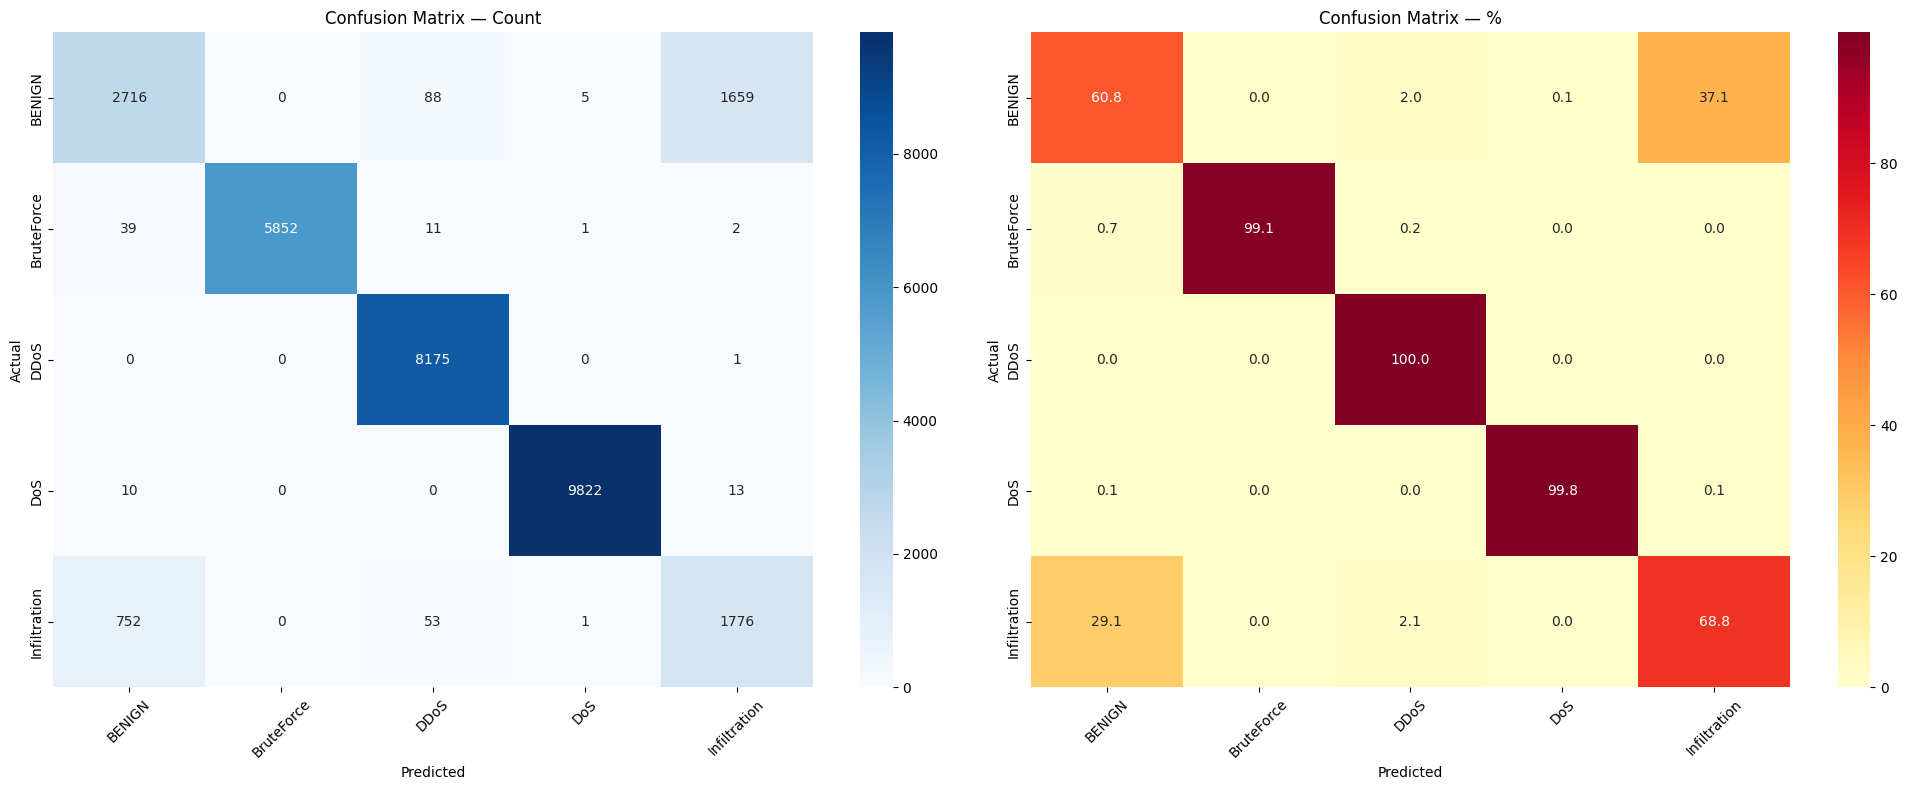

In [17]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Confusion Matrix — Count')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('Confusion Matrix — %')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---

## Cross-Dataset Evaluation — CIC-IDS 2017

The model trained on CIC-IDS 2018 is now evaluated on CIC-IDS 2017 to measure cross-dataset generalization.

### 18. Load CIC-IDS 2017 Dataset

Load the natural-distribution CIC-IDS 2017 sample for cross-dataset testing.

In [18]:
# Load CIC-2017 cross-test dataset (natural distribution)
CIC17_PATH = "../../../../dataset/cicids2017_sample_1M_natural_standardized.csv"
df17_raw = pd.read_csv(CIC17_PATH)
print(f"Shape: {df17_raw.shape}")
print(df17_raw['Label'].value_counts())


Shape: (864031, 79)
Label
BENIGN                        640639
DoS Hulk                      130108
DDoS                           72103
DoS GoldenEye                   5711
FTP-Patator                     4456
SSH-Patator                     3400
DoS slowloris                   3275
DoS Slowhttptest                3058
Web Attack � Brute Force         868
Web Attack � XSS                 361
Infiltration                      36
Heartbleed                        10
Web Attack � Sql Injection         6
Name: count, dtype: int64


### 19. Group CIC-IDS 2017 Attack Labels

Map 2017 fine-grained labels to the same 5 high-level categories used for CIC-2018 training (BENIGN, DoS, DDoS, BruteForce, Infiltration).

In [19]:
attack_group_mapping_17 = {
    # # BENIGN
    'BENIGN': 'BENIGN',

    # DoS / DDoS
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS Slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    
    'DDoS': 'DDoS',

    # Brute Force
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce',
    
    'Web Attack � XSS': 'BruteForce',
    'Web Attack � Brute Force': 'BruteForce',

    'Heartbleed': 'Infiltration',
    'Infiltration': 'Infiltration',
}

df17 = df17_raw.copy()
df17['Label'] = df17['Label'].map(attack_group_mapping_17)
df17.dropna(subset=['Label'], inplace=True)

for g, cnt in df17['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df17)*100:.2f}%)")


  BENIGN                  640,639  (74.43%)
  DoS                     138,877  (16.13%)
  DDoS                     72,103  (8.38%)
  BruteForce                9,085  (1.06%)
  Infiltration                 46  (0.01%)


### 20. Preprocess CIC-IDS 2017 Data

Apply the same preprocessing pipeline (inf handling, metadata drop) to the 2017 dataset and identify features shared with the CIC-2018 training set.

In [20]:
# Preprocess CIC-2017 with the same pipeline as training data
df17_proc = df17.copy()
df17_proc.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df17_proc.select_dtypes(include=[np.number]).columns:
    if df17_proc[col].isnull().sum() > 0:
        df17_proc[col].fillna(df17_proc[col].median(), inplace=True)

keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
df17_proc.drop(columns=[c for c in df17_proc.columns if any(k in c.lower() for k in keywords)],
               inplace=True, errors='ignore')

train_features = X_train.columns.tolist()
shared_features = [f for f in train_features if f in df17_proc.columns]
missing_in_17 = [f for f in train_features if f not in df17_proc.columns]

print(f"Shape: {df17_proc.shape}  |  Shared: {len(shared_features)}/{len(train_features)}  |  Missing: {len(missing_in_17)}")


/tmp/ipykernel_2364/2136018665.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df17_proc[col].fillna(df17_proc[col].median(), inplace=True)
/tmp/ipykernel_2364/2136018665.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

Shape: (860750, 78)  |  Shared: 34/35  |  Missing: 1


### 21. Method 1 — Cross-Test on CIC-IDS 2017 (No Retraining)

Directly evaluate the CIC-2018-trained model on CIC-2017 using shared features, without any retraining. Uses a model retrained on shared features only if features are missing in 2017.

In [21]:
# Method 1: Cross-test on CIC-2017 using shared features (no retrain)
X17 = df17_proc[shared_features]
y17_labels = df17_proc['Label']

mask_known = y17_labels.isin(set(le.classes_))
X17, y17_labels = X17[mask_known], y17_labels[mask_known]
y17 = le.transform(y17_labels)

if missing_in_17:
    RF_Shared = RandomForestClassifier(n_estimators=100, max_depth=10,
                                       min_samples_split=10, min_samples_leaf=4,
                                       random_state=42, n_jobs=-1)
    RF_Shared.fit(X_train[shared_features], y_train)
    acc18_shared = accuracy_score(y_test, RF_Shared.predict(X_test[shared_features]))
    y17_pred = RF_Shared.predict(X17)
    print(f"2018 test (all feats): {test_acc*100:.2f}%  |  2018 test (shared feats): {acc18_shared*100:.2f}%")
else:
    y17_pred = rf_classifier.predict(X17)

acc17_cross = accuracy_score(y17, y17_pred)
print(f"2018 test accuracy : {test_acc*100:.2f}%")
print(f"2017 cross accuracy: {acc17_cross*100:.2f}%")
print(f"Cross-dataset drop : {(test_acc - acc17_cross)*100:.2f}%\n")

present_indices = sorted(set(y17))
print(classification_report(y17, y17_pred, labels=present_indices,
                             target_names=le.inverse_transform(present_indices),
                             digits=4, zero_division=0))


2018 test (all feats): 91.49%  |  2018 test (shared feats): 92.92%
2018 test accuracy : 91.49%
2017 cross accuracy: 71.87%
Cross-dataset drop : 19.62%

              precision    recall  f1-score   support

      BENIGN     0.7853    0.8613    0.8216    640639
  BruteForce     0.2083    0.1883    0.1978      9085
        DDoS     0.2025    0.0207    0.0376     72103
         DoS     0.4963    0.4581    0.4764    138877
Infiltration     0.0001    0.0217    0.0001        46

    accuracy                         0.7187    860750
   macro avg     0.3385    0.3100    0.3067    860750
weighted avg     0.6837    0.7187    0.6936    860750



### 22. Method 2 — Cross-Test with StandardScaler Normalization

Fit a new `StandardScaler` on shared training features and re-evaluate cross-dataset performance after normalization. Compares scaled vs. unscaled accuracy.

In [22]:
# Method 2: Cross-test with StandardScaler normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[shared_features])
X_test_scaled  = scaler.transform(X_test[shared_features])
X17_scaled     = scaler.transform(X17)

RF_Scaler = RandomForestClassifier(n_estimators=100, max_depth=10,
                                    min_samples_split=10, min_samples_leaf=4,
                                    random_state=42, n_jobs=-1)
RF_Scaler.fit(X_train_scaled, y_train)

acc18_scaled = accuracy_score(y_test, RF_Scaler.predict(X_test_scaled))
acc17_scaled = accuracy_score(y17, RF_Scaler.predict(X17_scaled))

print(f"{'':30} {'No Scaler':>12} {'Scaler':>12}")
print(f"{'-'*55}")
print(f"{'2018 test accuracy':30} {test_acc*100:>11.2f}% {acc18_scaled*100:>11.2f}%")
print(f"{'2017 cross accuracy':30} {acc17_cross*100:>11.2f}% {acc17_scaled*100:>11.2f}%")
print(f"{'Cross-dataset drop':30} {(test_acc-acc17_cross)*100:>11.2f}% {(acc18_scaled-acc17_scaled)*100:>11.2f}%")


                                  No Scaler       Scaler
-------------------------------------------------------
2018 test accuracy                   91.49%       92.97%
2017 cross accuracy                  71.87%       74.39%
Cross-dataset drop                   19.62%       18.57%


### 23. Method 3 — Combined Training (CIC-2018 + CIC-2017)

Retrain the model on the combined CIC-2018 + CIC-2017 dataset (shared features, common classes) and evaluate on a stratified held-out split, reporting accuracy per dataset source.

In [23]:
# Method 3: Retrain on CIC-2018 + CIC-2017 combined, evaluate on stratified held-out split
X18_all = df_processed.drop(['Label', 'Label_Encoded'], axis=1, errors='ignore')[shared_features]
y18_all = df_processed['Label']
X17_all = df17_proc[shared_features]
y17_all = df17_proc['Label']

common_classes = set(y18_all.unique()) & set(y17_all.unique())
mask18 = y18_all.isin(common_classes)
mask17 = y17_all.isin(common_classes)

X_combined = pd.concat([X18_all[mask18], X17_all[mask17]], ignore_index=True)
y_combined_labels = pd.concat([y18_all[mask18], y17_all[mask17]], ignore_index=True)
source = pd.Series(['CIC18'] * mask18.sum() + ['CIC17'] * mask17.sum())

le_combined = LabelEncoder()
y_combined = le_combined.fit_transform(y_combined_labels)

X_comb_train, X_comb_test, y_comb_train, y_comb_test, src_train, src_test = \
    train_test_split(X_combined, y_combined, source, test_size=0.2, stratify=y_combined, random_state=42)

RF_combine = RandomForestClassifier(n_estimators=100, max_depth=10,
                                     min_samples_split=10, min_samples_leaf=4,
                                     random_state=42, n_jobs=-1)
RF_combine.fit(X_comb_train, y_comb_train)

acc_combined = accuracy_score(y_comb_test, RF_combine.predict(X_comb_test))
acc_18_part  = accuracy_score(y_comb_test[src_test.values == 'CIC18'],
                               RF_combine.predict(X_comb_test[src_test.values == 'CIC18']))
acc_17_part  = accuracy_score(y_comb_test[src_test.values == 'CIC17'],
                               RF_combine.predict(X_comb_test[src_test.values == 'CIC17']))

print(f"Overall accuracy  : {acc_combined*100:.2f}%")
print(f"CIC-2018 accuracy : {acc_18_part*100:.2f}%")
print(f"CIC-2017 accuracy : {acc_17_part*100:.2f}%")
print(f"Gap               : {abs(acc_18_part - acc_17_part)*100:.2f}%")


Overall accuracy  : 97.69%
CIC-2018 accuracy : 92.10%
CIC-2017 accuracy : 98.69%
Gap               : 6.59%


### 24. Classification Report + Confusion Matrix — Combined Model

Per-class performance on the combined CIC-2018 + CIC-2017 held-out test split using the jointly trained model.

              precision    recall  f1-score   support

      BENIGN     0.9771    0.9883    0.9827    132596
  BruteForce     0.9997    0.9170    0.9566      7722
        DDoS     0.9766    0.9975    0.9869     22597
         DoS     0.9726    0.9945    0.9834     37620
Infiltration     0.9307    0.1347    0.2353      2591

    accuracy                         0.9769    203126
   macro avg     0.9713    0.8064    0.8290    203126
weighted avg     0.9765    0.9769    0.9728    203126



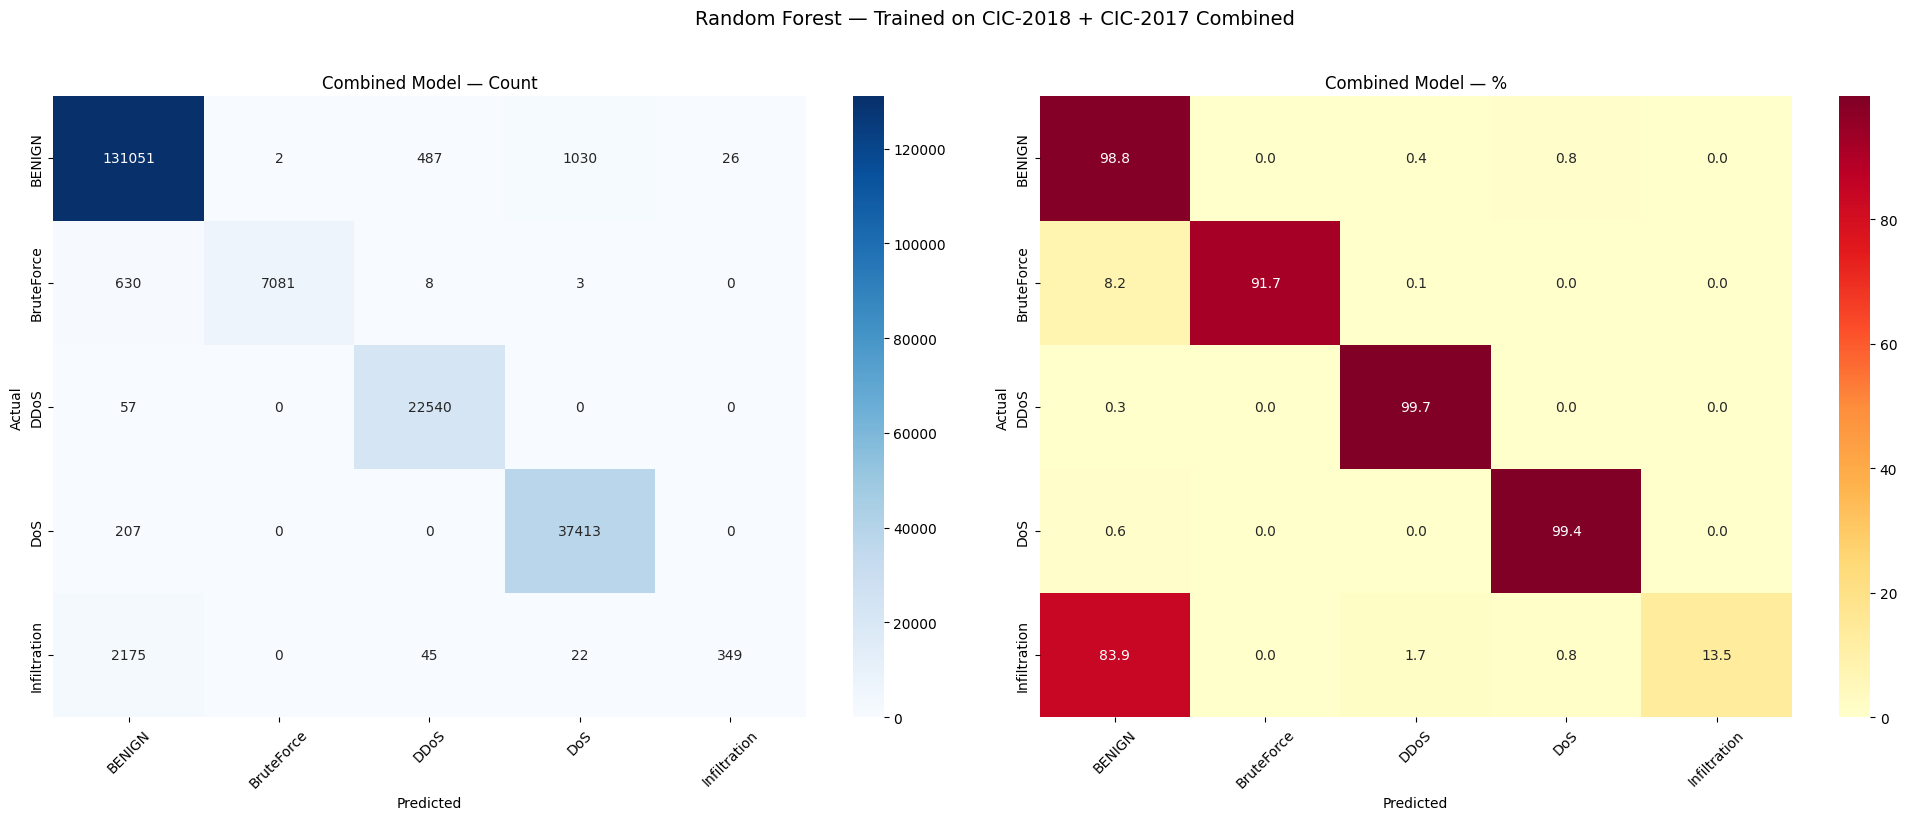

In [24]:
print(classification_report(y_comb_test, RF_combine.predict(X_comb_test),
                             target_names=le_combined.classes_, digits=4, zero_division=0))

cm_combined = confusion_matrix(y_comb_test, RF_combine.predict(X_comb_test))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_combined.classes_, yticklabels=le_combined.classes_, ax=ax1)
ax1.set_title('Combined Model — Count')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

cm_pct = cm_combined.astype(float) / cm_combined.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le_combined.classes_, yticklabels=le_combined.classes_, ax=ax2)
ax2.set_title('Combined Model — %')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Random Forest — Trained on CIC-2018 + CIC-2017 Combined', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
